In [20]:
import pandas as pd
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt

In [21]:
#Loaded the final sample dataset
df = pd.read_csv("FIFAWC2026_Final_Sample.csv")

print(df.head())

           player_name    Pos  MP  Min  goals  height_cm  weight_kg      Team  \
0  Gabriel Gudmundsson  MF,DF   4  330      0        181         73    Sweden   
1        Jules KoundÃ©     DF   8  599      0        178         83    France   
2           Malo Gusto     DF   5  121      0        179         69    France   
3         Julio Enciso     FW   5  386      1        168         63  Paraguay   
4          Matt Turner     GK   1   90      0        191         83       USA   

  team_status        BMI  
0    advanced  22.282592  
1    advanced  26.196187  
2    advanced  21.534908  
3    advanced  22.321429  
4    advanced  22.751569  


In [23]:
#Filter valid groups
#Count player in advanced group
#Count player in eliminated group
n_advanced_pop = len(df[df['team_status'] == 'advanced'])
n_eliminated_pop = len(df[df['team_status'] == 'eliminated'])

#Set target sample
target_sample_size = 50

#Adjust sample size if population is smaller than the target
sample_size = min(target_sample_size, n_advanced_pop, n_eliminated_pop)

if sample_size < target_sample_size:
    print(f"[Warning] Limited data available. Adjusting sample size per group to: {sample_size}")

#Split the populations
df_advanced_pop = df[df['team_status'] == 'advanced']
df_eliminated_pop = df[df['team_status'] == 'eliminated']

#Simple Random Sampling
sample_advanced = df_advanced_pop.sample(n=sample_size, random_state=42)
sample_eliminated = df_eliminated_pop.sample(n=sample_size, random_state=42)

#Counting for 95% Confidence Interval of population
for group_name, sub_df in [('Advanced', sample_advanced), ('Eliminated', sample_eliminated)]:
    data = sub_df['BMI']
    mean = np.mean(data)
    sem = stats.sem(data)
    ci = stats.t.interval(0.95, df=len(data)-1, loc=mean, scale=sem)
    print(f"Group [{group_name}]:")
    print(f"  - Sample BMI Mean: {mean:.4f}")
    print(f"  - 95% Confidence Interval for Population Mean: [{ci[0]:.4f}, {ci[1]:.4f}]")
print("--------------------------------------------------")

Group [Advanced]:
  - Sample BMI Mean: 23.0383
  - 95% Confidence Interval for Population Mean: [22.6175, 23.4590]
Group [Eliminated]:
  - Sample BMI Mean: 22.6373
  - 95% Confidence Interval for Population Mean: [22.2232, 23.0515]
--------------------------------------------------


In [24]:
#Separating player from the advanced and eliminated group
advanced = df[df["team_status"] == "advanced"]["BMI"]
eliminated = df[df["team_status"] == "eliminated"]["BMI"]

print("Advanced players:", len(advanced))
print("Eliminated players:", len(eliminated))


Advanced players: 50
Eliminated players: 50


In [25]:
# ============================================================
# 95% Confidence Interval of sample data
# ============================================================

#Calculate mean for each group
adv_mean = advanced.mean()
elim_mean = eliminated.mean()

#Calculate standard deviation for each group
adv_std = advanced.std()
elim_std = eliminated.std()

#Calculate sample size for each group
n_adv = len(advanced)
n_elim = len(eliminated)

#Calculate standard error for each group
adv_se = adv_std / np.sqrt(n_adv)
elim_se = elim_std / np.sqrt(n_elim)

#Calculate 95% confidence interval for advanced players
adv_ci_low, adv_ci_upp = st.t.interval(
    confidence=0.95,
    df=n_adv - 1,
    loc=adv_mean,
    scale=adv_se
)

#Calculate 95% confidence interval for eliminated players
elim_ci_low, elim_ci_upp = st.t.interval(
    confidence=0.95,
    df=n_elim - 1,
    loc=elim_mean,
    scale=elim_se
)

#Results
print("95%% Confidence Interval of Advanced Players: %.2f to %.2f"
      % (adv_ci_low, adv_ci_upp))

print("95%% Confidence Interval of Eliminated Players: %.2f to %.2f"
      % (elim_ci_low, elim_ci_upp))

95% Confidence Interval of Advanced Players: 22.62 to 23.46
95% Confidence Interval of Eliminated Players: 22.22 to 23.05


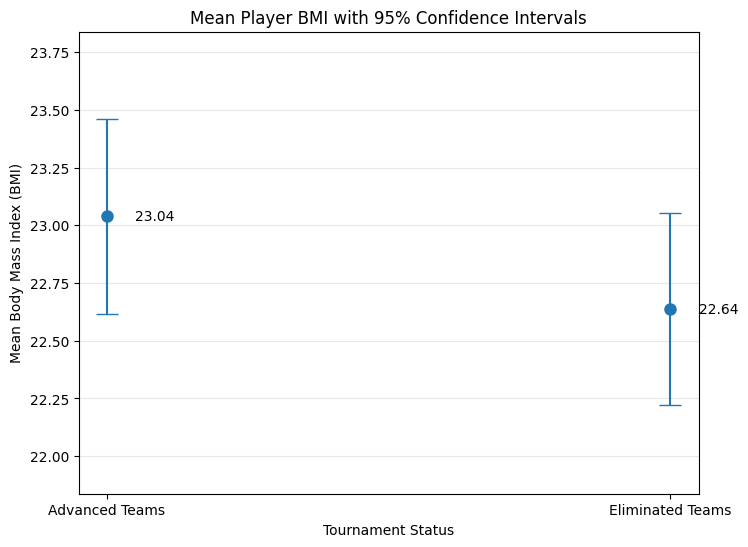

In [26]:
# ============================================================
# Visualize the 95% Confidence Intervals for Advanced and Eliminated
# ============================================================

groups = ["Advanced Teams", "Eliminated Teams"]
means = [adv_mean, elim_mean]

#Distance from mean to CI boundaries
errors = [
    [adv_mean - adv_ci_low, elim_mean - elim_ci_low],
    [adv_ci_upp - adv_mean, elim_ci_upp - elim_mean]
]

plt.figure(figsize=(8, 6))

plt.errorbar(
    groups,
    means,
    yerr=errors,
    fmt="o",
    capsize=8,
    markersize=8
)

# Add mean labels
for i, mean in enumerate(means):
    plt.text(
        i + 0.05,
        mean,
        f"{mean:.2f}",
        ha="left",
        va="center"
    )

plt.ylabel("Mean Body Mass Index (BMI)")
plt.xlabel("Tournament Status")
plt.title("Mean Player BMI with 95% Confidence Intervals")

#Set Y limits to show the means more clearly
plt.ylim(min(means) - 0.8, max(means) + 0.8)

plt.grid(axis="y", alpha=0.3)
plt.show()
